# Example 1 — Attitude Control of a Spacecraft

This example demonstrates the construction of a spacecraft simulation focused on rotational dynamics and attitude control.

### Notes and repository setup

Initial imports and repository-path configuration used by the example.

In [32]:
import numpy as np
from pathlib import Path
import sys

path = Path.cwd()

REPO_ROOT = path.parents[1]

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

## General Simulation Setup

ARGOS can work with multiple spacecrafts at a time, however, before defining any spacecraft, we need to define a common simulation setup

### Environment

The environment object provides the simulation environment in which the spacecrafts dynamics are evaluated.

In [33]:
from py.modules.enviroments.environments import ClassicalEnvironment

env = ClassicalEnvironment()

### Simulation setup

The `Simulation` object defines the overall simulation horizon and environment. This works as a central orchestator for each spacecraft that will be added to the sim.

*Note: All the units in the simulations are in the Inertational Metric System*

In [34]:
from py.modules.new.simulation import Simulation

sim = Simulation(max_sim_time=5*60, # 3 minutes,                 
                 environment= env,                 
                 verbose = True
)

## Spacecraft Creation

To create an spacecraft, several things need to be define depending on the level of detail wanted. The things included are:

- Actuators
- Sensors
- Mission Manager
- Target

In the following example, we will address basic definitions and creations of the three first items

### Actuators

Actuators will introduce in the simulation external forces and torques, the actuators could ither be controllable or not.

For example, a solid rocket motor will not be controllable, while RCS thrusters are.

In this case, as we are doing an attitude control problem, a set of RCS thrusters will be defined

#### RCS Thruster

The RCS Thruster class, is inteded to replicate the principal functional and operational capabilities of a real RCS thruster.
Therefore, if we want a full authority in the 3 DOFs and the 2 directions in each axis, we need a total of 6 thrusters.

Despite the class supports a position definition of the thruster (and base on that, calculate the torque exerted over the CG), in preliminary designs, the position may not be available, but torque is still wanted. In those cases, we can not define the position, but define an torque value that will automatically override the internal calculation output (that will be zero due to the not definition of the position)

Note that the class also allows different command method, by default, we have a PWM method

In [35]:
from py.modules.actuators.RCS import RCSThruster

thruster_X_pos = RCSThruster(
    nominal_thrust= 0,
    direction= np.array([1, 0, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thruster_X_neg = RCSThruster(
    nominal_thrust= 0,
    direction= np.array([-1, 0, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
    
)

thruster_Y_pos = RCSThruster(
    nominal_thrust= 0,
    direction= np.array([0, 1, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thruster_Y_neg = RCSThruster(
    nominal_thrust= 0,
    direction= np.array([0, -1, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thruster_Z_pos = RCSThruster(
    nominal_thrust= 0,
    direction= np.array([0, 0, 1]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0   
)

thruster_Z_neg = RCSThruster(
    nominal_thrust= 0,
    direction= np.array([0, 0, -1]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thrusters = [thruster_X_pos, thruster_X_neg, thruster_Y_pos, thruster_Y_neg, thruster_Z_pos, thruster_Z_neg]

As mention later, an actuator can be controllable (or not). Can be available or not (for example in a two stage rocket with solid motors, the second stage motor could be available but not be active, and once we get there, both stafs motor will not be available as they are single used), and thefeore we can also see if the actuator has been use We can access this information, with the following methods

In [36]:
print(thruster_Z_neg.is_available())
print(thruster_Z_neg.has_been_used())
print(thruster_Z_neg.is_controllable())

True
False
True


Or access a more general information with

In [37]:
thruster_X_pos.print_information()

RCS Thruster Information:
Is controllable: True
Is available: True
Has been used: False
Nominal Thrust: 0 N
Position: [0. 0. 0.]
Direction: [1. 0. 0.]
Command Mode: PWM
Modulation Window: 0.1 s
Minimum On Time: 0.01 s
Activation Threshold: 0.0 N
Override Torque Enabled: Yes
Override Torque Value: 300 Nm


### Sensors

Sensors are a key item in any system, specially when any type of control is wanted.

Various sensors type are defined, however, in this example, we will not cover them, for more information there, see **. 

However, as we are proposing a control system, and in general, anytime we want to evaluate the performance of a control or guidance algorithm, we want to test them with the real/perfect data.

In those cases, we can use the AbsoluteSensor, that will simply "copy-paste" the true state variables, which are the dynamic integrated variables

In any sensor, we need to define a Sample Rate in Hz, which will define the interval in which the sensor will update the data that is seeing

In [38]:
from py.modules.sensors.generic_sensor import AbsoluteSensor

sensors = [AbsoluteSensor(100, verbose=False)]  # Sample rate of 100 Hz

### Mission Manager

All spacecrafts need a mission manager, this class, as its name indicates will store different mission phases

A phase is basically a portion of the whole simulation where different GNC laws or propagators are needed.

For example, we can have a nominal phase, where certain GNC laws are used, and a off nominal phase, where the GNC laws changes

In that sameway, when multiple phases are defined, transitions need to be defined, this will not be covered here, but is covered in the example 4.

#### Mission Phase

As it was mention, the mission phase will have (or not) define different GNC laws and propagators, therefore, to create a phase, we need to first define the items that will be used in that specific phase

##### Propagators

The propagator defines the dynamical model and numerical integration method used by the simulation. It can be defined indenentply a translational propagator, and a rotational propagaotr, in this case, as we are defining a rotational example, the translational propagaotr will be ignore

By default, the `NativeRotationalPropagaotr` uses the Euler equations with quaternions.

This will be added later to a mission phase.

In [39]:
from py.modules.propagators.native_propagator import NativeRotationalPropagator

rot_propagator = NativeRotationalPropagator(integration_method="NATIVE_RK45")

##### Guidance

If any control is desired, a guidance law is needed, as this will set the reference variables that the controller will follow.

A custom guidance law can be defined using the CustomGuidanceLaw class, this class will have access to the navigation_estiamted data (that will be cover in the next step) and the information of the simulation, and is needed that returns a GuidanceReference dataclass

In [40]:
# Next step is define the guidance law
from py.general.dataclasses import GuidanceReference, StateVariables
from py.modules.guidance.basic_laws import CustomGuidanceLaw
from py.modules.math import quaternion_from_euler

objective_orientation = [0, 0, 0]  # Desired orientation in Euler angles (degrees)


def compute_reference(navigation_estimated_data, simulation_data):

    ref = GuidanceReference(
        state=StateVariables(
            attitude=quaternion_from_euler(
                np.deg2rad(objective_orientation[0]),
                np.deg2rad(objective_orientation[1]),
                np.deg2rad(objective_orientation[2]),
            )
        )
    )
    return ref

guidance_law = CustomGuidanceLaw(
    custom_reference_function= compute_reference
)

However, some guidance laws are already implemented, as a constant reference guidance law, which is the one that we need in this example, as across the whole phase, the reference will be the same

In [41]:
from py.modules.guidance.basic_laws import ConstantReferenceGuidance

guidance_law = ConstantReferenceGuidance(
    desired_quat = quaternion_from_euler(np.deg2rad(objective_orientation[0]), np.deg2rad(objective_orientation[1]), np.deg2rad(objective_orientation[2]))
)

##### Navigation

If a guidance law is beeing used, then is mandatory to have a navigation law, how ever, it is not mandatory in the other way, as sometimes it is only wanted to have a test of filters and estimation algorithms.

Similar to the guidance law, it is possible to define custom navigation laws using the CustomNavigation Class, for this, the input will be only the sensors that the spacecraft has, therefore, you will not have access to the real/true states (unless you defined an Absolute Sensor)

In [42]:
from py.general.dataclasses import EstimationOutput
from py.modules.navigation.basic_laws import CustomNavigation

def estimate(sensors):

    for sensor in sensors:
        if sensor.type   == "AbsoluteSensor":
            sensor_data = sensor.get_measurement()                

            estimated_attitude = sensor_data[0][3]
            estimated_angular_velocity = sensor_data[0][4]            

            return EstimationOutput(
                spacecraft_attitude=estimated_attitude,
                spacecraft_angular_velocity=estimated_angular_velocity
            )                

navigation_law = CustomNavigation(
    custom_estimation_function=estimate
)

Again, there are some already defined navigation laws, as we initially talked about not using any sensor model, but use the absolute sensor to test de control law, we need to keep the same philosophy here, anf therefore an Ideal Navifation law is already implemented, which will automatically translate the real/true states into the estimation output (that is used bot in the reference/guidance module, and in the control module)

In [43]:
from py.modules.navigation.basic_laws import IdealNavigation

navigation_law = IdealNavigation()  # Using the ideal navigation law for this example

##### Control

The control module works pretty similar to the guidance and navigation modules, beeing able to define a full custom model, or use one of the already implemented laws.

In this case, we will use a PD Attitude Controller

In [44]:
from py.modules.controllers.classic_controllers import PDAttitudeController

control_law = PDAttitudeController(
    proportional_gain= 1000,
    derivative_gain= 20000,
    maximum_torque= 1000,
    minimum_torque= -1000
)

##### Control allocation

As the control module will just generate the control reference (in both, force and torque needed to achieve the guidance law), we need a allocator algorithm that will translate that need, in physical allocation between the actuators that are defined.

Once again, custom and already implemented methods can be used as show:

In [45]:
from py.modules.controllers.basic_laws import CustomControlAllocator

def allocate(control_output, actuators):
    
    torque_to_allocate = control_output.torque

    # Extract direction and magnitude of the torque to allocate
    torque_magnitude = np.linalg.norm(torque_to_allocate)
    torque_direction = torque_to_allocate / torque_magnitude if torque_magnitude != 0 else np.zeros(3)
    
    for actuator in actuators:
        # Calculate the dot product between the actuator's direction and the torque direction
        dot_product = np.dot(actuator.direction, torque_direction)
        # If the dot product is positive, the actuator can contribute to the torque
        if dot_product > 0:
            # Allocate a portion of the torque to this actuator based on its direction
            allocated_torque = dot_product * torque_magnitude
            #print(f"Allocating torque {allocated_torque} to actuator with direction {actuator.direction}")
            # Set the actuator's command based on the allocated torque                
            actuator.set_command(allocated_torque)
        else:
            # If the actuator cannot contribute, set its command to zero
            actuator.set_command(0)

allocator_law = CustomControlAllocator(
    allocation_function= allocate
)

The same basic algorithm previusly shown, is implemented in the BasicRCSAllocator, wich will assume 6 RCS thrusters where the torque will be allocated

In [46]:
from py.modules.controllers.basic_laws import BasicRCSAllocator

allocator_law = BasicRCSAllocator()

##### Mission phase and mission manager definition

As all the minimum things are already defined, we can move on and create the mission phase and mission manager objects

For the mission phase, additional to the previusly discussed items, we need to provide an unique name for the phase, and the update rates for each of the laws and propagators in seconds

In [47]:
from py.general.dataclasses import MissionPhase

phase = MissionPhase(
    name="SinglePhase",
    guidance= guidance_law,
    navigation= navigation_law,
    controller= control_law,

    allocator = allocator_law,

    dt_nav = 0.1,  # Navigation update rate (10 Hz)
    dt_guid = 1,  # Guidance update rate (1 Hz)
    dt_control = 0.1, # Control update rate (10 Hz)

    rotational_model= rot_propagator,
    dt_propagation= 0.01 # Propagation time step (100 Hz)
)

With that, we can set this phase ad the initial phase in the mission manager, in this example, it is not covered how to add phases and transitions, this is covered in the example 4

In [48]:
from py.modules.new.mission_manager import MissionManager

mission_manager = MissionManager(
    initial_phase= phase
)

### Spacecraft initialization

With all the previus step completed, we can now move to create the spacecraft, where the inertial parameters need to be added, as well as the initial conditions and all the thre previus elements

In [49]:
# With all this, we can now add an spacecraft to the sim
from py.modules.math import quaternion_from_euler
from py.general.general_data import Ix_total, Iy_total, Iz_total

initial_vel = np.array([0.0, 0.0, 0.0])  # Initial velocity in meters per second
initial_orientation = initial_orientation = [45, -30, -10]  # Initial orientation in Euler angles (degrees)
initial_orientation_quat = quaternion_from_euler(np.deg2rad(initial_orientation[0]), np.deg2rad(initial_orientation[1]), np.deg2rad(initial_orientation[2]))
initial_angular_velocity = np.array([-0.08, 0.05, 0.1])  # Initial angular velocity in rad/s

sim.add_spacecraft(    
    initial_attitude= initial_orientation_quat,
    initial_angular_velocity= initial_angular_velocity,
    inertia_tensor= np.diag([Ix_total, Iy_total, Iz_total]),  # Inertia tensor in kg*m^2
    actuators = thrusters,
    sensors = sensors,
    mission_manager = mission_manager,
    verbose = True
)

Mass not provided. Using default mass of 0 kg.
Initial position not provided. Using default position of [0, 0, 0].
Initial velocity not provided. Using default velocity of [0, 0, 0].
========== Spacecraft created successfully. ==========
Spacecraft Name: Spacecraft_1
Mass: 0.0 kg
Inertia Tensor: 
[[80921.72163479     0.             0.        ]
 [    0.         80921.72163479     0.        ]
 [    0.             0.         61091.        ]]
NOT IMPLEMENTED: GNC information display is not yet implemented.
NOT IMPLEMENTED: Spacecraft state information display is not yet implemented.
========== End of spacecraft information. ==========
Spacecraft 'Spacecraft_1' added to the simulation.


### Simulation execution and results

Now the simulation can be executed

In [50]:
# We can now simulate
result = sim.simulate()

Initializing simulation...
Spacecraft 'Spacecraft_1' dt_nav: 0.1, dt_guid: 1, dt_control: 0.1
Simulation initialized.
Starting simulation...
Simulation completed.


The results of the simulation can be access via the result variable, for more information on the data format of the result check **

Some plotting functions are already defined as shown below

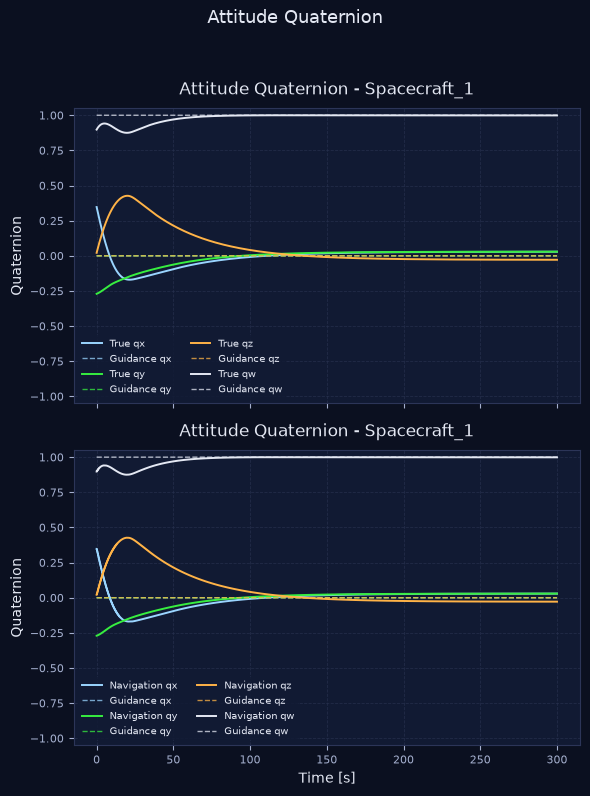

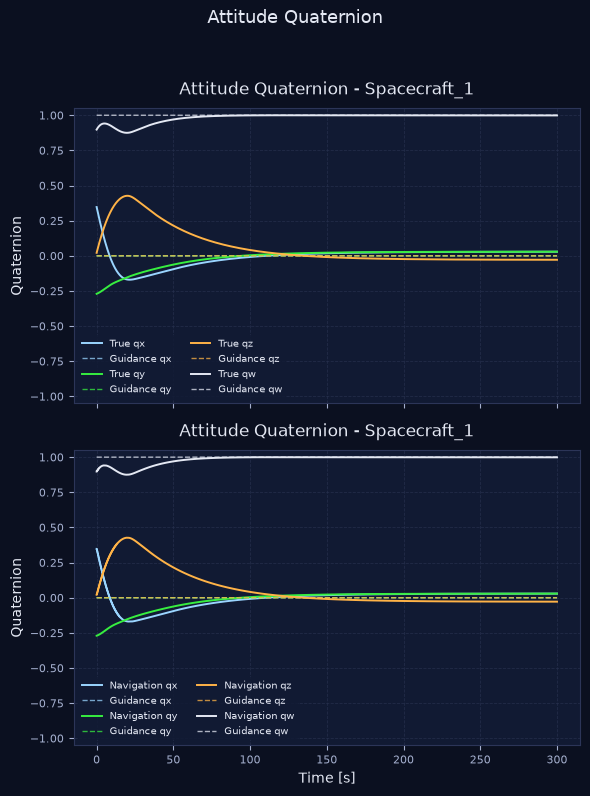

In [ ]:
from py.modules.visualization.state_variables import plot_attitude_quaternions, plot_angular_velocity, plot_position
from py.modules.visualization.gnc import plot_control_result

plot_attitude_quaternions("Spacecraft_1", result)

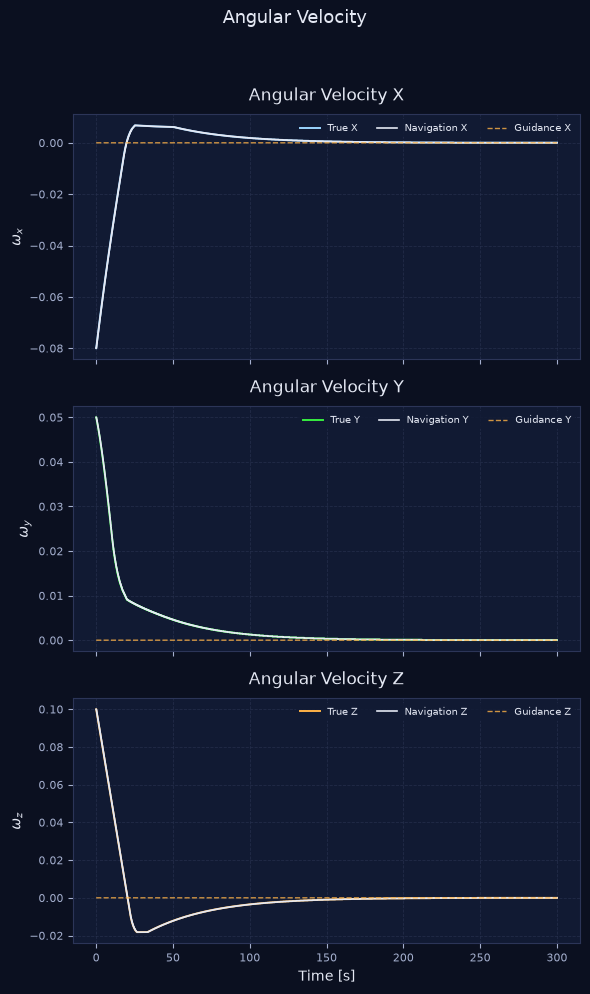

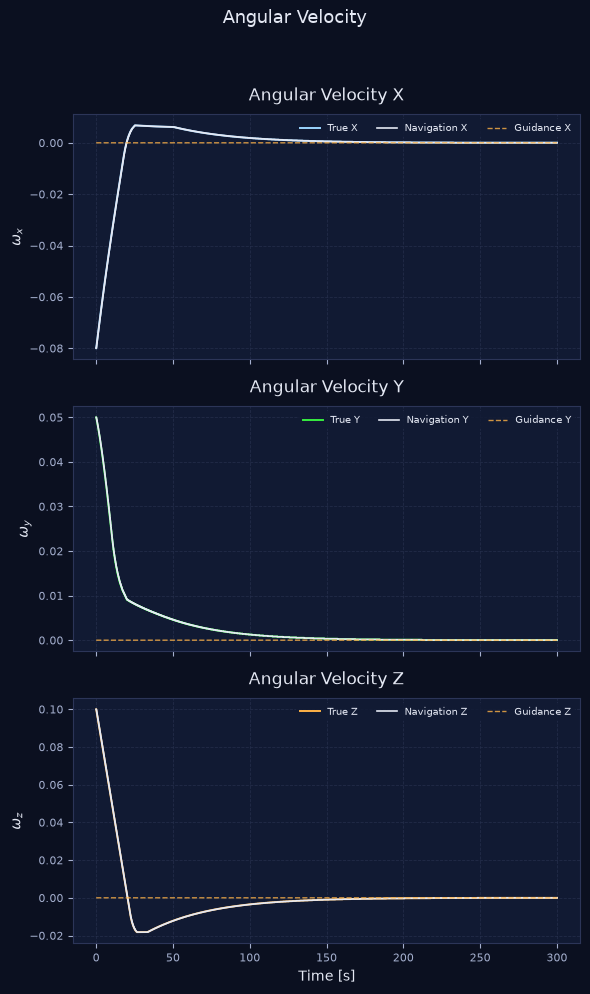

In [52]:
plot_angular_velocity("Spacecraft_1", result)

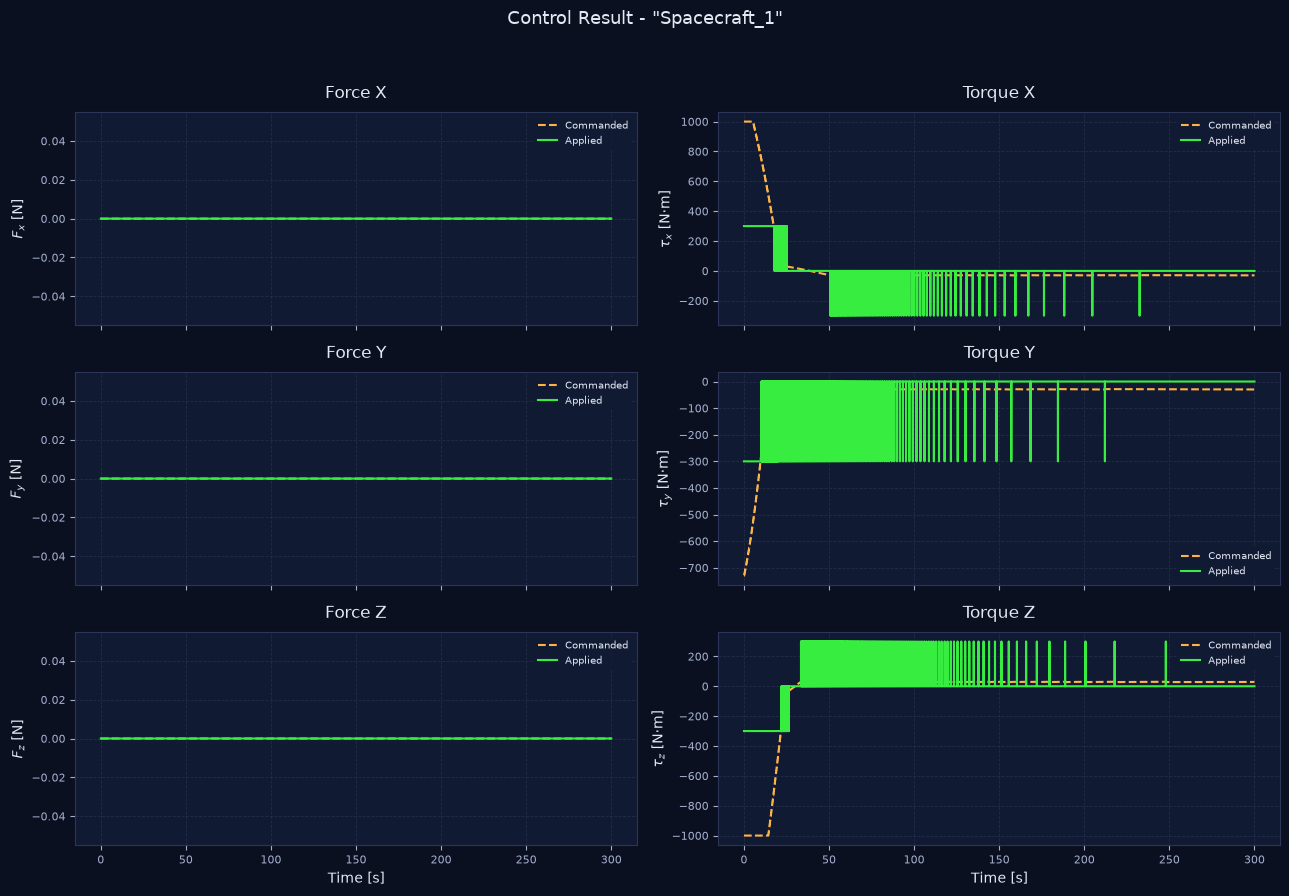

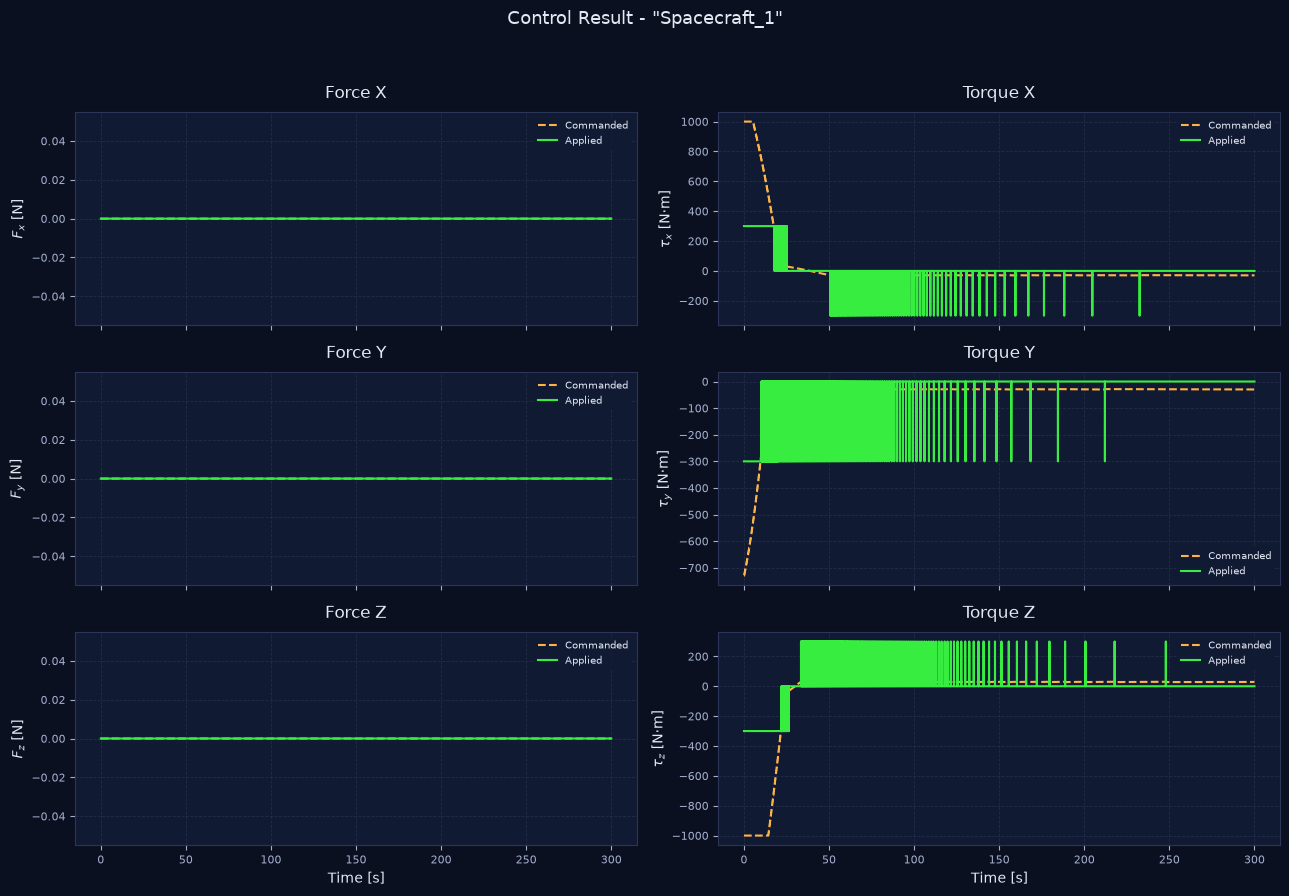

In [53]:
plot_control_result("Spacecraft_1", result)

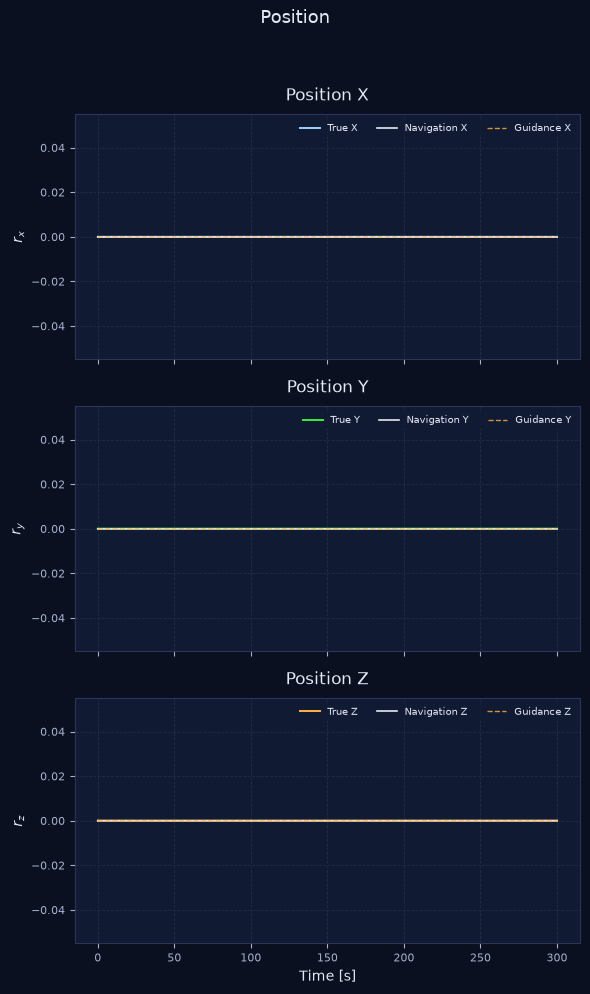

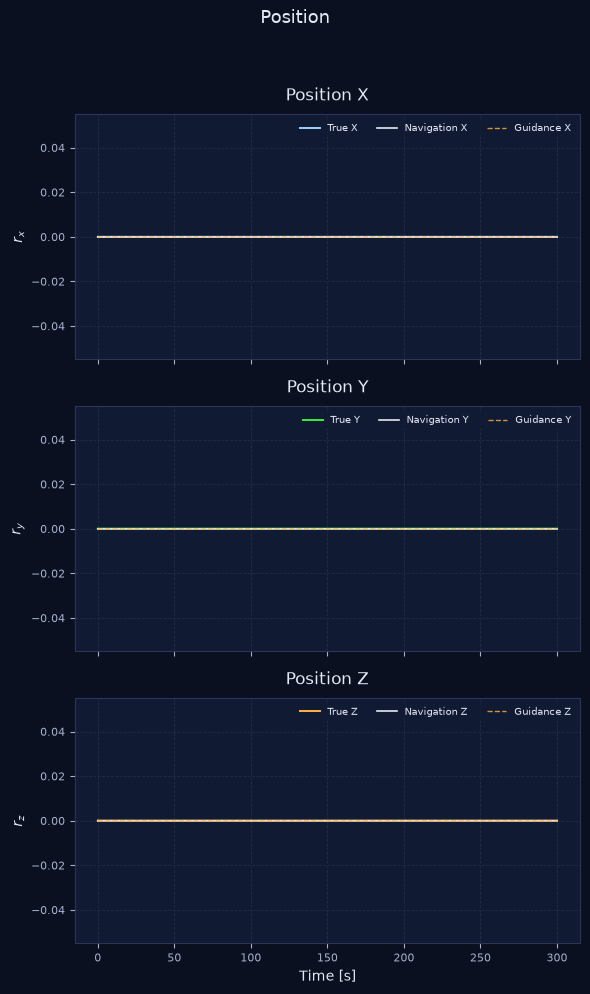

In [54]:
plot_position("Spacecraft_1", result)
